# Cross-Function Quantitative Analysis

This notebook consolidates the realised optimisation performance of **Functions 1–8** into one scale-free view and compares the main surrogate-validation diagnostics reported in the eight source notebooks.

Because the eight objectives have very different numerical scales — from approximately \(10^{-16}\) for Function 1 to thousands for Function 5 — their raw objective values should **not** be overlaid directly. The main graph therefore normalises each function's incumbent path by its own total observed improvement:

\[
p_t = \frac{b_t-b_0}{b_{13}-b_0},
\]

where \(b_0\) is the initial incumbent and \(b_t\) is the best value observed by week \(t\).

Thus:
- **0** = initial incumbent;
- **1** = final best observed value;
- a steeper early rise means more of the eventual improvement was captured earlier.

### Source notebooks

- `Function_1(7).ipynb`
- `Function_2(6).ipynb`
- `Function_3(7).ipynb`
- `Function_4(7).ipynb`
- `Function_5(4).ipynb`
- `Function_6(5).ipynb`
- `Function_7(4).ipynb`
- `Function_8(5).ipynb`

The realised query outputs and surrogate-validation statistics below are taken from the executed outputs of those notebooks. The analysis does not infer hidden objective values at unevaluated points.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

WEEKS = np.arange(0, 14)
QUERY_WEEKS = np.arange(1, 14)

## 1. Realised query-budget performance

The table below reconstructs the initial incumbent and the 13 realised sequential query outputs for each function. These are the values used in the original per-function summary plots.

In [2]:
performance_records = {
    1: {
        "dimension": 2, "initial_observations": 10,
        "initial": 7.710875114502849e-16,
        "queries": [1.23e-139, -6.43e-160, 3.18e-201, 4.06e-177, 1.75e-26,
                    -1.23e-20, 8.81e-56, 1.07e-63, 7.23e-16, 7.47e-18,
                    7.52e-16, 7.83e-16, 8.19e-16],
    },
    2: {
        "dimension": 2, "initial_observations": 10,
        "initial": 0.611205,
        "queries": [-0.012804, 0.331094, 0.612394, 0.062186, 0.377662,
                    0.265357, 0.579392, 0.501180, 0.632404, 0.515447,
                    0.613833, 0.498144, 0.543542953],
    },
    3: {
        "dimension": 3, "initial_observations": 15,
        "initial": -0.034835,
        "queries": [-0.028417, -0.032890, -0.113217, -0.140421, -0.061293,
                    -0.007682, -0.134673, -0.019876, -0.008646, -0.007074,
                    -0.013293, -0.006264, -0.008104],
    },
    4: {
        "dimension": 4, "initial_observations": 30,
        "initial": -4.025542,
        "queries": [-0.179152, 0.158268, -0.242767, -0.980711, 0.085640,
                    0.037359, 0.255738, -1.710300, 0.303945, 0.521892,
                    0.585186, -4.573956, 0.435511],
    },
    5: {
        "dimension": 4, "initial_observations": 20,
        "initial": 1088.859618,
        "queries": [1489.609415, 1500.250566, 3294.679200, 5553.031467,
                    8662.482500, 7786.371350, 7786.371350, 7786.371350,
                    7786.371350, 7915.738969, 8471.231482, 8471.231482,
                    8471.231482],
    },
    6: {
        "dimension": 5, "initial_observations": 20,
        "initial": -0.714265,
        "queries": [-0.265439, -0.901414, -0.801380, -0.441430, -0.437764,
                    -0.251672, -0.219614, -0.501144, -0.319201, -0.202749,
                    -0.103406, -0.390235, -0.302745],
    },
    7: {
        "dimension": 6, "initial_observations": 30,
        "initial": 1.364968,
        "queries": [1.701689, 1.017737, 2.329548, 1.734759, 2.580636,
                    2.736811, 2.684600, 2.772707, 2.384170, 2.832769,
                    2.625874, 2.773992, 2.854626],
    },
    8: {
        "dimension": 8, "initial_observations": 40,
        "initial": 9.598482,
        "queries": [9.727050, 9.789550, 9.155800, 9.694292, 9.940738,
                    9.939507, 9.902744, 9.954129, 9.993086, 9.939253,
                    9.975729, 9.953449, 9.977170],
    },
}

def performance_metrics(function_id, record):
    initial = float(record["initial"])
    queries = np.asarray(record["queries"], dtype=float)
    best = np.maximum.accumulate(np.r_[initial, queries])
    final = float(best[-1])
    total_gain = final - initial
    progress = (best - initial) / total_gain

    improvements = np.diff(best) > 0
    final_week = int(np.where(best == final)[0][0])
    w50 = int(np.where(progress >= 0.50)[0][0])
    w90 = int(np.where(progress >= 0.90)[0][0])

    return {
        "function": f"F{function_id}",
        "dimension": record["dimension"],
        "initial_n": record["initial_observations"],
        "initial_incumbent": initial,
        "final_best": final,
        "absolute_gain": total_gain,
        "relative_gain": total_gain / abs(initial),
        "improving_queries": int(improvements.sum()),
        "hit_rate": float(improvements.mean()),
        "best_found_week": final_week,
        "week_50pct_gain": w50,
        "week_90pct_gain": w90,
        "gain_by_W5": float(progress[5]),
        "gain_by_W8": float(progress[8]),
        "progress_auc": float(np.trapezoid(progress, x=WEEKS) / 13.0),
        "tail_queries_after_best": 13 - final_week,
        "best_path": best,
        "progress": progress,
    }

metrics = {
    f_id: performance_metrics(f_id, record)
    for f_id, record in performance_records.items()
}

performance_summary = pd.DataFrame([
    {k: v for k, v in m.items() if k not in {"best_path", "progress"}}
    for m in metrics.values()
])

display(
    performance_summary[[
        "function", "dimension", "initial_n",
        "initial_incumbent", "final_best", "relative_gain",
        "improving_queries", "hit_rate", "best_found_week",
        "week_50pct_gain", "week_90pct_gain",
        "gain_by_W5", "gain_by_W8", "progress_auc",
        "tail_queries_after_best",
    ]].style.format({
        "initial_incumbent": "{:.6g}",
        "final_best": "{:.6g}",
        "relative_gain": "{:.1%}",
        "hit_rate": "{:.1%}",
        "gain_by_W5": "{:.1%}",
        "gain_by_W8": "{:.1%}",
        "progress_auc": "{:.3f}",
    })
)

,function,dimension,initial_n,initial_incumbent,final_best,relative_gain,improving_queries,hit_rate,best_found_week,week_50pct_gain,week_90pct_gain,gain_by_W5,gain_by_W8,progress_auc,tail_queries_after_best
0,F1,2,10,7.71088e-16,8.19e-16,6.2%,2,15.4%,13,13,13,0.0%,0.0%,0.058,0
1,F2,2,10,0.611205,0.632404,3.5%,2,15.4%,9,9,9,5.6%,5.6%,0.372,4
2,F3,3,15,-0.034835,-0.006264,82.0%,4,30.8%,12,6,6,22.5%,95.0%,0.644,1
3,F4,4,30,-4.02554,0.585186,114.5%,6,46.2%,11,1,2,90.7%,92.9%,0.896,2
4,F5,4,20,1088.86,8662.48,695.6%,5,38.5%,5,4,5,100.0%,100.0%,0.730,8
5,F6,5,20,-0.714265,-0.103406,85.5%,5,38.5%,11,1,11,73.5%,81.0%,0.784,2
6,F7,6,30,1.36497,2.85463,109.1%,7,53.8%,13,3,6,81.6%,94.5%,0.750,0
7,F8,8,40,9.59848,9.99309,4.1%,5,38.5%,9,5,8,86.7%,90.1%,0.752,4


### Reading the cross-function metrics

- **Hit rate**: fraction of the 13 queries that improved the incumbent.
- **Best found week**: first week at which the final incumbent was observed.
- **Week 50% / 90% gain**: when the search first captured 50% / 90% of its eventual improvement.
- **Gain by W5 / W8**: fraction of eventual improvement already realised by those dates.
- **Progress AUC**: area under the normalised incumbent curve; higher means improvement was captured earlier.
- **Tail queries after best**: evaluations performed after the final incumbent had already been found.

`relative_gain` is useful inside each function, but it is **not a fair ranking statistic across functions**, especially when objectives have different origins, signs or scales.

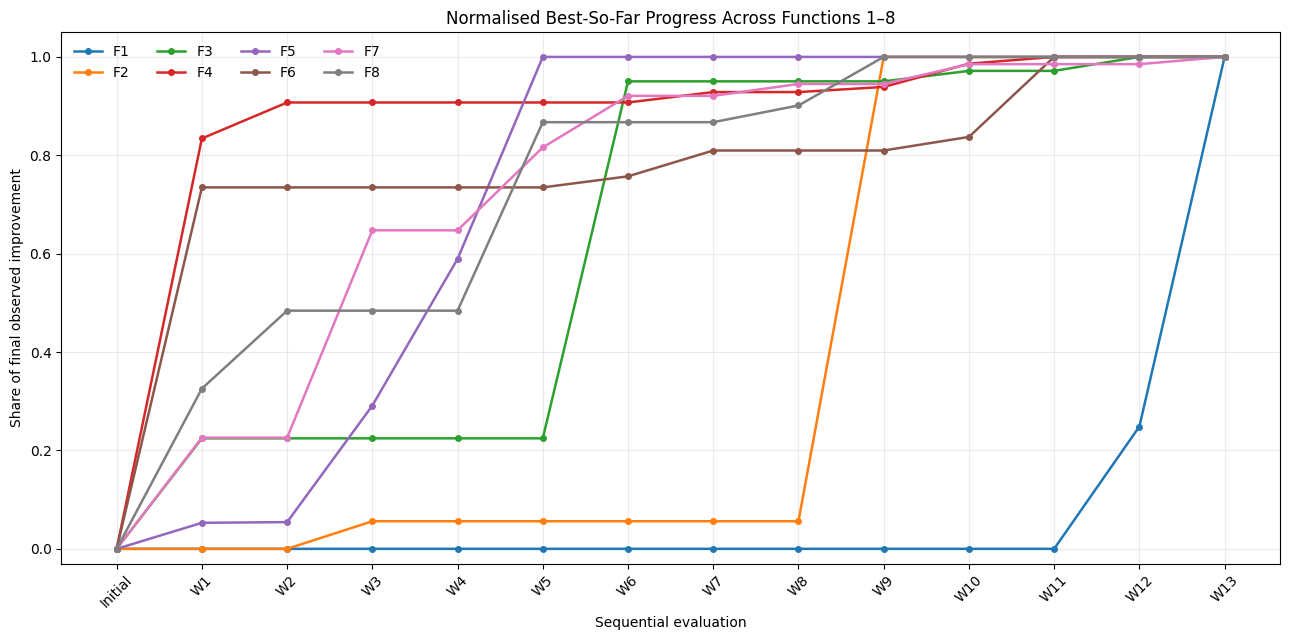

In [3]:
# One scale-free summary graph for all eight per-function summary plots.
fig, ax = plt.subplots(figsize=(13, 6.5))

for f_id, m in metrics.items():
    ax.plot(
        WEEKS,
        m["progress"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=f"F{f_id}",
    )

ax.set_title("Normalised Best-So-Far Progress Across Functions 1–8")
ax.set_xlabel("Sequential evaluation")
ax.set_ylabel("Share of final observed improvement")
ax.set_xticks(WEEKS)
ax.set_xticklabels(["Initial"] + [f"W{i}" for i in range(1, 14)], rotation=45)
ax.set_ylim(-0.03, 1.05)
ax.grid(alpha=0.25)
ax.legend(ncol=4, frameon=False)
fig.tight_layout()

fig.savefig("summary_all_functions.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Quantitative performance feedback

The normalised paths reveal materially different discovery profiles.

- **F4 is the strongest early-discovery case.** Week 1 already captures roughly **83%** of the eventual gain; 91% is reached by Week 2. Its progress AUC is the highest of the eight functions.
- **F5 is the clearest early-convergence case.** The first five queries all improve the incumbent and the final best is reached at **W5**. The remaining **8 queries** are therefore better interpreted as boundary diagnostics than optimisation gains.
- **F7 has the highest improvement hit rate: 7/13 = 53.8%.** Its search keeps producing improvements across the full budget and the final incumbent arrives at **W13**.
- **F6 combines a very strong W1 jump with useful late refinement.** About 73% of the final gain is captured immediately, but the local phase still adds the final material improvement at **W11**.
- **F8 captures 86.7% of its total gain by W5 and reaches the final incumbent at W9.** The last four queries are local confirmation rather than additional improvement.
- **F3 is a mid-budget success.** The decisive improvement arrives at W6; about 95% of the final gain is already captured by that point, followed by smaller refinements at W10 and W12.
- **F2 is relatively low-efficiency in realised improvement terms.** Only W3 and W9 improve the incumbent, and the final gain is modest. The four evaluations after W9 are diagnostic.
- **F1 is the most delayed discovery profile.** None of W1–W11 improves the initial incumbent; W12 and W13 produce the only two gains. Its very low progress AUC reflects a search whose value is concentrated almost entirely in the final directional refinement.

The key point is that the same 13-query budget served different purposes across functions: in some cases it was still actively optimising late in the run (F1, F7), while in others the optimum observed under the budget had already been found and the remaining evaluations were primarily robustness checks (especially F5, and to a lesser extent F2/F8).

## 3. Surrogate robustness across functions

The following values are the LOOCV diagnostics reported in the eight source notebooks. Raw RMSE values should **not** be compared across functions because each objective has a different scale. The useful cross-function quantities are:

1. the **percentage RMSE reduction versus that function's baseline historical RBF specification**; and
2. the **best within-function Spearman rank correlation**.

In [4]:
surrogate_records = {
    1: [
        ("RBF_fixed", 0.000785, -0.645257),
        ("RBF_bounded", 0.000766, 0.538538),
        ("Matern_32", 0.000761, 0.516798),
    ],
    2: [
        ("RBF_fixed", 0.245174, 0.131423),
        ("RBF_fitted_bounded", 0.223547, 0.438735),
        ("Matern_52", 0.200138, 0.577075),
    ],
    3: [
        ("RBF_fitted", 0.078720, 0.518336),
        ("Matern_52", 0.071436, 0.721949),
    ],
    4: [
        ("RBF_fitted", 1.965952, 0.970100),
        ("Matern_52", 1.146407, 0.984144),
    ],
    5: [
        ("RBF_historical", 302.086705, 0.856450),
        ("Matern_52", 279.375724, 0.883387),
    ],
    6: [
        ("RBF_global", 0.299873, 0.923463),
        ("Matern_52_global", 0.314533, 0.904078),
        ("Matern_52_local", 0.286944, 0.914439),
    ],
    7: [
        ("Global RBF", 0.320815, 0.844458),
        ("Global Matern_52", 0.330370, 0.875717),
        ("Local Matern_52", 0.266632, 0.841438),
    ],
    8: [
        ("Global RBF", 0.257860, 0.973875),
        ("Global Matern_52", 0.117918, 0.987986),
        ("Local Matern_52", 0.128815, 0.991130),
    ],
}

surrogate_rows = []

for f_id, rows in surrogate_records.items():
    baseline = rows[0]
    best_rmse = min(rows, key=lambda x: x[1])
    best_rank = max(rows, key=lambda x: x[2])

    surrogate_rows.append({
        "function": f"F{f_id}",
        "baseline_kernel": baseline[0],
        "best_rmse_kernel": best_rmse[0],
        "best_rmse": best_rmse[1],
        "rmse_reduction_vs_baseline": (baseline[1] - best_rmse[1]) / baseline[1],
        "best_spearman_kernel": best_rank[0],
        "best_spearman": best_rank[2],
        "same_kernel_wins_both": best_rmse[0] == best_rank[0],
    })

surrogate_summary = pd.DataFrame(surrogate_rows)

display(
    surrogate_summary.style.format({
        "best_rmse": "{:.6g}",
        "rmse_reduction_vs_baseline": "{:.1%}",
        "best_spearman": "{:.3f}",
    })
)

,function,baseline_kernel,best_rmse_kernel,best_rmse,rmse_reduction_vs_baseline,best_spearman_kernel,best_spearman,same_kernel_wins_both
0,F1,RBF_fixed,Matern_32,0.000761,3.1%,RBF_bounded,0.539,False
1,F2,RBF_fixed,Matern_52,0.200138,18.4%,Matern_52,0.577,True
2,F3,RBF_fitted,Matern_52,0.071436,9.3%,Matern_52,0.722,True
3,F4,RBF_fitted,Matern_52,1.14641,41.7%,Matern_52,0.984,True
4,F5,RBF_historical,Matern_52,279.376,7.5%,Matern_52,0.883,True
5,F6,RBF_global,Matern_52_local,0.286944,4.3%,RBF_global,0.923,False
6,F7,Global RBF,Local Matern_52,0.266632,16.9%,Global Matern_52,0.876,False
7,F8,Global RBF,Global Matern_52,0.117918,54.3%,Local Matern_52,0.991,False


### Surrogate feedback

- **F8 provides the strongest evidence for the historical RBF → Matérn transition.** The best Matérn specification cuts LOOCV RMSE by about **54%** versus the global RBF, while all tested models retain extremely high rank correlation.
- **F4 also shows a material Matérn advantage:** about **42%** lower RMSE and Spearman around **0.984**.
- **F2 and F3 favour Matérn on both criteria**, with RMSE reductions of about **18%** and **9%**, respectively, and improved ranking.
- **F5 shows a modest Matérn improvement** rather than a decisive model-form change: roughly **7.5%** lower RMSE and a small Spearman increase.
- **F6 is genuinely mixed.** The local Matérn has the lowest RMSE, but the global RBF has the highest Spearman. The differences are small enough that the evidence supports model-family robustness more than a unique winner.
- **F7 is also mixed.** Local Matérn gives the best RMSE, while global Matérn gives the best Spearman. That is consistent with the notebook's more cautious conclusion that local modelling helps value prediction without proving one specification dominates every criterion.
- **F1 remains the hardest surrogate-ranking problem.** The best Spearman is only about **0.54**, and the tiny/needle-like response scale makes global predictive validation much less convincing than the late observed directional evidence.

Across the eight functions, there is therefore **no single universally dominant kernel**. Matérn variants are strongly supported for F2/F3/F4/F8, moderately helpful for F5/F7, while F6 is model-form robust and F1 remains intrinsically difficult to rank predictively.

## 4. Function-by-function quantitative synthesis

In [5]:
feedback = pd.DataFrame([
    {
        "function": "F1",
        "profile": "Very late discovery",
        "quantitative_evidence": "2/13 improvements; W50=W13; AUC≈0.058",
        "feedback": "Global/model-driven phases did not beat the initial incumbent. The final directional probes are the entire realised improvement story; conclusions should remain local and empirical.",
    },
    {
        "function": "F2",
        "profile": "Sparse improvement + local boundary optimum",
        "quantitative_evidence": "2/13 improvements; best at W9; 4 tail queries",
        "feedback": "The final gain is small but cleanly localised. Matérn is the strongest retrospective surrogate. W10–W13 are best framed as robustness/shape diagnostics.",
    },
    {
        "function": "F3",
        "profile": "Mid-budget step change",
        "quantitative_evidence": "95% of gain by W6; best at W12",
        "feedback": "The global-to-improvement transition is productive. Later local search adds only incremental value after the decisive W6 jump.",
    },
    {
        "function": "F4",
        "profile": "Exceptional early discovery + gradual refinement",
        "quantitative_evidence": "83% of gain at W1; 6/13 improvements; AUC≈0.896",
        "feedback": "Strongest early efficiency in the set. Matérn validation is also very strong. Later queries refine an already excellent region rather than rescue the search.",
    },
    {
        "function": "F5",
        "profile": "Fast convergence to boundary/corner",
        "quantitative_evidence": "5 consecutive improvements; final best at W5; 8 tail queries",
        "feedback": "Optimisation effectively finishes by W5. The rest of the budget provides valuable local boundary evidence, but should not be counted as continued optimisation efficiency.",
    },
    {
        "function": "F6",
        "profile": "Large early jump + useful local completion",
        "quantitative_evidence": "73% of gain at W1; final best at W11",
        "feedback": "The initial global search is highly effective and the local phase still contributes materially. Kernel diagnostics support robustness rather than a single dominant model.",
    },
    {
        "function": "F7",
        "profile": "Most consistently productive budget",
        "quantitative_evidence": "7/13 improvements; 53.8% hit rate; final best at W13",
        "feedback": "Best improvement frequency of the eight functions. The budget remains useful through the last query, supporting the staged global-to-local search narrative.",
    },
    {
        "function": "F8",
        "profile": "Rapid high-dimensional localisation",
        "quantitative_evidence": "86.7% of gain by W5; final best at W9; AUC≈0.752",
        "feedback": "Despite eight dimensions, the search localises quickly. The Matérn transition has the strongest validation support in the set; W10–W13 mainly confirm the final neighbourhood.",
    },
])

display(feedback.style.set_properties(
    subset=["profile", "quantitative_evidence", "feedback"],
    **{"white-space": "normal"}
))

,function,profile,quantitative_evidence,feedback
0,F1,Very late discovery,2/13 improvements; W50=W13; AUC≈0.058,Global/model-driven phases did not beat the initial incumbent. The final directional probes are the entire realised improvement story; conclusions should remain local and empirical.
1,F2,Sparse improvement + local boundary optimum,2/13 improvements; best at W9; 4 tail queries,The final gain is small but cleanly localised. Matérn is the strongest retrospective surrogate. W10–W13 are best framed as robustness/shape diagnostics.
2,F3,Mid-budget step change,95% of gain by W6; best at W12,The global-to-improvement transition is productive. Later local search adds only incremental value after the decisive W6 jump.
3,F4,Exceptional early discovery + gradual refinement,83% of gain at W1; 6/13 improvements; AUC≈0.896,Strongest early efficiency in the set. Matérn validation is also very strong. Later queries refine an already excellent region rather than rescue the search.
4,F5,Fast convergence to boundary/corner,5 consecutive improvements; final best at W5; 8 tail queries,"Optimisation effectively finishes by W5. The rest of the budget provides valuable local boundary evidence, but should not be counted as continued optimisation efficiency."
5,F6,Large early jump + useful local completion,73% of gain at W1; final best at W11,The initial global search is highly effective and the local phase still contributes materially. Kernel diagnostics support robustness rather than a single dominant model.
6,F7,Most consistently productive budget,7/13 improvements; 53.8% hit rate; final best at W13,"Best improvement frequency of the eight functions. The budget remains useful through the last query, supporting the staged global-to-local search narrative."
7,F8,Rapid high-dimensional localisation,86.7% of gain by W5; final best at W9; AUC≈0.752,"Despite eight dimensions, the search localises quickly. The Matérn transition has the strongest validation support in the set; W10–W13 mainly confirm the final neighbourhood."


## 5. Overall conclusion

The consolidated evidence suggests four broad optimisation patterns:

1. **Early discovery:** F4 and F6 extract most of their eventual gain almost immediately.
2. **Fast convergence followed by diagnostics:** F5 is the clearest example; F2 and F8 also have meaningful post-best diagnostic tails.
3. **Progressive multi-phase optimisation:** F3 and especially F7 continue to benefit from later phases.
4. **Late rescue / highly local discovery:** F1 improves only in the final two directional evaluations.

For cross-function comparison, **normalised progress AUC and hit rate are more defensible than raw or relative objective gains**. Raw gains are on incomparable scales, and relative gains can be distorted by objectives close to zero or initially negative.

The strongest model-level pattern is that **Matérn surrogates become increasingly useful in several functions, but not uniformly**. F4 and F8 show particularly strong retrospective support for Matérn; F6 and F7 show a more nuanced split between value-prediction RMSE and rank preservation.

Finally, the eight notebooks support a consistent methodological limitation: these are analyses of the **best observed configurations under a fixed 13-query budget**. Neither the combined graph nor the validation tables prove that any final incumbent is the global maximum, nor do they establish a controlled counterfactual ranking of the different historical acquisition policies.